In [ ]:
# import the different libraries: numpy, pandas, mathplotlib.pyplot and statsmodels.api

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# setting floating numbers rounded to 2 decimals
pd.options.display.float_format = '{:.2f}'.format

# importing the csv data file
HS_data = pd.read_csv('AICPA_regressionAnalysisData.csv')

display(HS_data) # displaying the variable

,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114
5,dt4training,2011-06-30,10379712,479264,239,4
6,dt4training,2011-07-31,13617528,708472,486,0
7,dt4training,2011-08-31,14092512,687728,346,0
8,dt4training,2011-09-30,12085472,567424,195,19
9,dt4training,2011-10-31,11957032,392328,24,223


In [ ]:
HS_data['date']= pd.to_datetime(HS_data['date']) #converting column date to a datetime object

# create two dummy variables - one for winter and one for fall
# a dummy variable takes a value of 0 or 1 to represent the absence or presence of a condition
# for example, in this case, the condition is, if the months are 12, 1 and 2 (dec, jan and feb), then return 1, or else return 0

HS_data['winter_DV'] = np.where(HS_data['date'].dt.month.isin([12,1,2]),1,0)

HS_data['fall_DV'] = np.where(HS_data['date'].dt.month.isin([9,10,11]),1,0)

In [ ]:
#interaction term is just our indepenent variable * dummy variable
# created a interaction term with winter and fall data

HS_data['winter_interaction'] = HS_data['production'] * HS_data['winter_DV']

HS_data['fall_interaction'] = HS_data['production'] * HS_data['fall_DV']

In [ ]:
# spilting the data set into a testing and training set

dt4training = HS_data.loc[HS_data['type']=='dt4training']

dt4testing = HS_data.loc[HS_data['type']=='dt4testing']

In [ ]:
# train our model

y = dt4training.loc[:,'revenue']
x = dt4training.loc[:,['production','winter_DV','winter_interaction']]
x2 = dt4training.loc[:,['production','fall_DV','fall_interaction']]

x = sm.add_constant(x)
x2 = sm.add_constant(x2)

model1 = sm.OLS(y,x).fit()
model2 = sm.OLS(y,x2).fit()

display(model1.params)
display(model2.params)

,0
const,5629257.08
production,13.51
winter_DV,-201742.73
winter_interaction,14.16


,0
const,6118386.30
production,18.30
fall_DV,-477240.43
fall_interaction,-7.67


In [ ]:
#calculate mape score for model1 (winter)

x_test = dt4testing.loc[:,['production','winter_DV', 'winter_interaction']]
x_test = sm.add_constant(x_test)

model1_assessment = dt4testing.copy()

model1_assessment['model1_predicted_revenue'] = model1.predict(x_test)

model1_assessment['model1_abs_pct_error'] = abs(
    (model1_assessment['revenue'] - model1_assessment['model1_predicted_revenue']
     )/model1_assessment['revenue']
    )

display(model1_assessment)


,type,date,revenue,production,coolDD,heatDD,winter_DV,fall_DV,winter_interaction,fall_interaction,model1_predicted_revenue,model1_abs_pct_error
36,dt4testing,2014-01-31,19228840,606400,0,1123,1,0,606400,0,22205317.42,0.15
37,dt4testing,2014-02-28,26792280,714128,0,938,1,0,714128,0,25185922.91,0.06
38,dt4testing,2014-03-31,19935840,805600,0,866,0,0,0,0,16509348.78,0.17
39,dt4testing,2014-04-30,13468000,375856,0,412,0,0,0,0,10705408.70,0.21
40,dt4testing,2014-05-31,7344128,279296,49,88,0,0,0,0,9401310.32,0.28
41,dt4testing,2014-06-30,11196216,517600,230,0,0,0,0,0,12619743.01,0.13
42,dt4testing,2014-07-31,13929472,749472,380,0,0,0,0,0,15751307.84,0.13
43,dt4testing,2014-08-31,12352176,663432,322,0,0,0,0,0,14589288.11,0.18
44,dt4testing,2014-09-30,12628944,701656,178,14,0,1,0,701656,15105525.23,0.20
45,dt4testing,2014-10-31,9361000,411728,24,166,0,1,0,411728,11189880.71,0.20


In [ ]:
#calculate mape score for model2 (fall)

x2_test = dt4testing.loc[:,['production','fall_DV', 'fall_interaction']]
x2_test = sm.add_constant(x2_test)

model2_assessment = dt4testing.copy()

model2_assessment['model2_predicted_revenue'] = model2.predict(x2_test)

model2_assessment['model2_abs_pct_error'] = abs(
    (model2_assessment['revenue'] - model2_assessment['model2_predicted_revenue']
     )/model2_assessment['revenue']
    )

display(model2_assessment)


,type,date,revenue,production,coolDD,heatDD,winter_DV,fall_DV,winter_interaction,fall_interaction,model2_predicted_revenue,model2_abs_pct_error
36,dt4testing,2014-01-31,19228840,606400,0,1123,1,0,606400,0,17216499.43,0.10
37,dt4testing,2014-02-28,26792280,714128,0,938,1,0,714128,0,19188098.26,0.28
38,dt4testing,2014-03-31,19935840,805600,0,866,0,0,0,0,20862185.66,0.05
39,dt4testing,2014-04-30,13468000,375856,0,412,0,0,0,0,12997166.66,0.03
40,dt4testing,2014-05-31,7344128,279296,49,88,0,0,0,0,11229960.52,0.53
41,dt4testing,2014-06-30,11196216,517600,230,0,0,0,0,0,15591313.99,0.39
42,dt4testing,2014-07-31,13929472,749472,380,0,0,0,0,0,19834951.34,0.42
43,dt4testing,2014-08-31,12352176,663432,322,0,0,0,0,0,18260278.43,0.48
44,dt4testing,2014-09-30,12628944,701656,178,14,0,1,0,701656,13103874.26,0.04
45,dt4testing,2014-10-31,9361000,411728,24,166,0,1,0,411728,10020235.10,0.07


In [ ]:
display(model1_assessment['model1_abs_pct_error'].mean()) #mape score
display(model2_assessment['model2_abs_pct_error'].mean()) #mape score

np.float64(0.15896219012848184)

np.float64(0.2201698389944771)

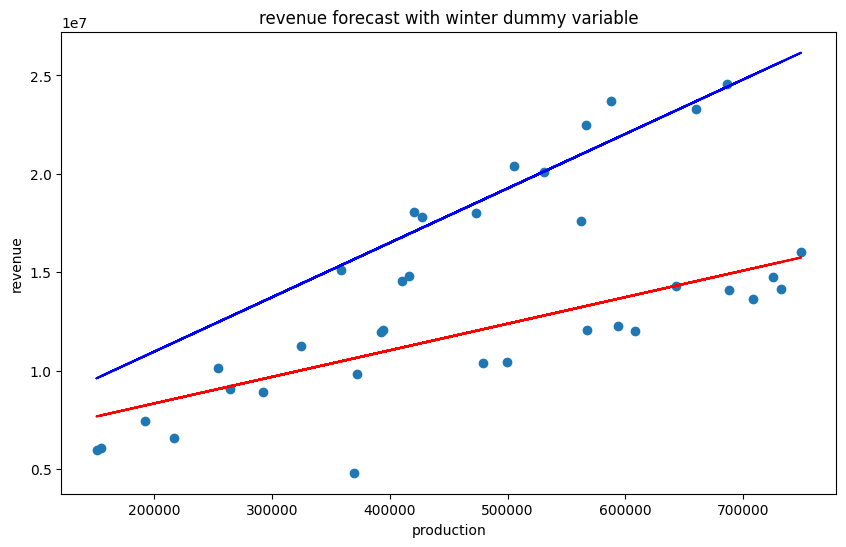

In [ ]:
# creating the graph, adding features (winter)

plt.figure(figsize=(10,6))

plt.title('revenue forecast with winter dummy variable')
plt.xlabel('production')
plt.ylabel('revenue')

# visualizing a regression with dummy variables is to scatter plot the actual datpoints
plt.scatter(dt4training['production'],dt4training['revenue'])

# extract the coefficient from our model
intercept, production_coefficient, winter_DV_intercept, winter_coefficient = model1.params

# create individual lines for winter and non winter
non_winter_line = intercept + production_coefficient * dt4training['production']

winter_line = (intercept + winter_DV_intercept) + (production_coefficient + winter_coefficient) * dt4training['production']

# step 4 plot the y values against the x values for our intercept
plt.plot(dt4training['production'],non_winter_line, color = 'red')
plt.plot(dt4training['production'],winter_line, color = 'blue')

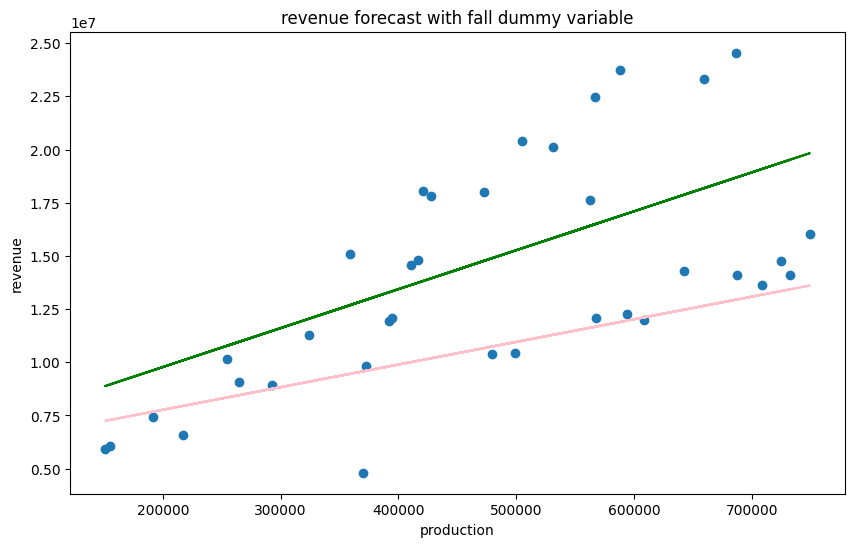

In [ ]:
# creating the graph, adding features (fall)
plt.figure(figsize=(10,6))

plt.title('revenue forecast with fall dummy variable')
plt.xlabel('production')
plt.ylabel('revenue')

# visualizing a regression with dummy variables is to scatter plot the actual datpoints
plt.scatter(dt4training['production'],dt4training['revenue'])

# extract the coefficient from our model
intercept, production_coefficient, fall_DV_intercept, fall_coefficient = model2.params

# create individual lines for winter and non winter
non_fall_line = intercept + production_coefficient * dt4training['production']

fall_line = (intercept + fall_DV_intercept) + (production_coefficient + fall_coefficient) * dt4training['production']

# step 4 plot the y values against the x values for our intercept
plt.plot(dt4training['production'],non_fall_line, color = 'green')
plt.plot(dt4training['production'],fall_line, color = 'pink')

MEMORANDUM

To Hotazel Steam

From Adelaide Woo

July 17, 2026

RE: Highlights from Each Revenue Forecast

Our team constructued two models - winter and fall, and created a forecast for each model using a dummy variable and interaction term. Our team also computed the MAPE score for each mdoel.

Based on our observations, the best model is production + winter because it has a MAPE score of 15.90%, compared to production + fall with a larger MAPE score of 22.02%.


Recommendation. We recommend pursuing Model 1 as it is more accurate.